# 온도 데이터가 몇 초 간격으로 기록되었는지 확인하기

**담당: 정수진**  ·  관련 Issue: #10 (번호를 채우세요)

## 이 노트북에서 할 일

온도 CSV의 측정 시각(`MEAS_DT`)을 보고, 데이터가 **몇 초마다 한 번씩** 찍혔는지 알아냅니다.

## 왜 하는지

간격을 모르면 나중에 "1분 평균", "10분 이동평균" 같은 걸 계산할 때 기준을 정할 수 없습니다.
또 간격이 일정하지 않다면 그 자체가 설비나 계측기의 문제 신호일 수 있습니다.

## 진행 방법

1. 아래 칸을 **위에서부터 순서대로** 실행하세요.
2. `# TODO` 라고 적힌 곳을 직접 채우세요. 막히면 디스코드에 물어보세요.
3. 맨 아래 **결과 정리** 칸에 확인한 값을 한국어 문장으로 적으세요. 이게 진짜 결과물입니다.
4. 다 했으면 커밋 전에 맨 마지막 안내를 읽으세요.

> 데이터 파일이 없으면 `data/` 폴더에 CSV 3개를 먼저 넣으세요. 이 파일들은 Git에 올라가지 않습니다(공유받은 자료를 각자 직접 넣습니다).

## 공통 준비

In [7]:
# 이 칸은 그대로 실행하세요. 데이터 경로를 잡아둡니다.
import os
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_DIR = os.path.join("..", "data")          # notebooks 폴더 기준 한 단계 위의 data 폴더
TEMP_CSV   = os.path.join(DATA_DIR, "T-CR1-CAL01_온도.csv")
EVENT_CSV  = os.path.join(DATA_DIR, "G-02_조업이벤트.csv")
REPAIR_CSV = os.path.join(DATA_DIR, "G-01_정기수리캘린더.csv")

pd.set_option("display.max_columns", 50)
print("경로 확인:", os.path.exists(TEMP_CSV), os.path.exists(EVENT_CSV), os.path.exists(REPAIR_CSV))

경로 확인: True True True


# 컬럼명
| 컬럼 | 추정 의미 | 추정 의미 확실성 |
| --- | --- | --- |
| `MEAS_DT` | 측정 일시 | 확정 가능 |
| `LOT_NO` | 생산 LOT 번호 | 확정 가능 |
| `CLN-IN` | Cleaning 구간 입측 측정값 | 추정 |
| `TC-Z1` ~ `TC-Z9` | Zone 1~9 온도 또는 열전대 값 | 높은 추정 |
| `TC-OUT1`, `TC-OUT2` | 출측 온도 1·2 | 높은 추정 |
| `OP-Z1` ~ `OP-Z8` | Zone별 출력, 조작량 또는 밸브 개도율 | 추정 |
| `CP-Z4` | Zone 4 제어값 또는 압력 관련 값 | 불확실 |
| `CP-Z4M` | Zone 4 제어값의 보정·모델값 등 | 매우 불확실 |

### 1단계 — 온도 데이터를 읽고 시각 컬럼을 날짜 형식으로 바꾸세요

CSV에서 읽으면 `MEAS_DT`는 그냥 글자(문자열)입니다.
글자끼리는 빼기를 할 수 없으니, 먼저 **날짜/시간 형식으로 바꿔야** 간격을 계산할 수 있습니다.

In [12]:
# read_csv는 CSV를 표 형태의 DataFrame으로 읽습니다. 한글이 있으므로 UTF-8 인코딩을 지정합니다.
df = pd.read_csv(TEMP_CSV, encoding="utf-8")

# MEAS_DT를 날짜/시간 형식으로 변환합니다. 변환할 수 없는 값은 NaT가 됩니다.
# errors='coerce'를 사용하면 형식이 잘못된 값이 오류를 중단시키지 않고 NaT(날짜 결측값)로 바뀝니다.
df["MEAS_DT"] = pd.to_datetime(df["MEAS_DT"], errors="coerce")

print(df.shape)       # (행 수, 열 수)
print(df.dtypes.head())  # MEAS_DT가 datetime64로 바뀌었는지 확인합니다.
print("시각 변환 실패:", df["MEAS_DT"].isna().sum(), "건")
print("측정 기간:", df["MEAS_DT"].min(), "~", df["MEAS_DT"].max())

(345390, 24)
MEAS_DT    datetime64[us]
LOT_NO              int64
CLN-IN            float64
TC-Z1             float64
TC-Z2             float64
dtype: object
시각 변환 실패: 0 건
측정 기간: 2024-01-02 03:36:00 ~ 2024-12-28 16:44:24


### 2단계 — 시각을 순서대로 정렬하고, 바로 앞 행과의 시간 차이를 구하세요

파일에 적힌 순서가 시간 순서라는 보장이 없습니다. 먼저 정렬하세요.
그다음 `.diff()` 를 쓰면 **바로 위 행과의 차이**를 구할 수 있습니다.

In [13]:
# LOT 사이의 장기 비가동 시간이 측정 간격에 포함되지 않도록 LOT와 시각으로 정렬합니다.
# sort_values는 LOT를 먼저 묶고 각 LOT 안에서 측정 시각이 빠른 순서로 배치합니다.
# reset_index(drop=True)는 정렬 전 행 번호를 버리고 0부터 새 행 번호를 붙입니다.
df = df.sort_values(["LOT_NO", "MEAS_DT"]).reset_index(drop=True)

# 같은 LOT 내부에서만 바로 앞 측정과의 시간 차이를 계산합니다.
# groupby는 LOT별로 데이터를 나누고, diff는 현재 시각에서 같은 LOT의 직전 시각을 뺍니다.
# 각 LOT의 첫 행은 비교할 이전 행이 없으므로 결과가 NaT가 됩니다.
gap = df.groupby("LOT_NO")["MEAS_DT"].diff()


# gap 은 "0 days 00:00:01" 같은 형태입니다. 초 단위 숫자로 바꾸면 보기 편합니다.
# total_seconds는 시간 차이를 초 단위 실수로 바꾸고, dropna는 LOT별 첫 행을 계산에서 제외합니다.
gap_sec = gap.dt.total_seconds().dropna()

# 0초는 중복 시각, 음수는 시간 역순을 의미하므로 함께 점검합니다.
print("계산한 LOT 내부 간격:", f"{len(gap_sec):,}", "개")
print("0초 간격:", int((gap_sec == 0).sum()), "건")
print("음수 간격:", int((gap_sec < 0).sum()), "건")

계산한 LOT 내부 간격: 345,376 개
0초 간격: 0 건
음수 간격: 0 건


### 3단계 — 어떤 간격이 몇 번 나왔는지 세어 보세요

`value_counts()` 는 값별 등장 횟수를 세어줍니다.
가장 위에 나오는 값이 **가장 흔한 간격**입니다.

In [14]:
# 간격별 발생 건수와 전체 대비 비율을 한 표로 확인합니다.
# value_counts는 같은 간격이 몇 번 등장했는지 셉니다. sort_index는 1초, 2초 순으로 정렬합니다.
# normalize=True이면 건수 대신 0~1 비율을 반환하므로 100을 곱해 백분율로 만듭니다.
interval_summary = pd.DataFrame({
    "건수": gap_sec.value_counts().sort_index(),
    "비율_%": (gap_sec.value_counts(normalize=True).sort_index() * 100).round(4),
})
display(interval_summary)

,건수,비율_%
MEAS_DT,,
1.0,334966,96.9859
2.0,10372,3.0031
3.0,31,0.0090
5.0,1,0.0003
6.0,2,0.0006
10.0,1,0.0003
11.0,3,0.0009


### 4단계 — 한 문장으로 정리해 보세요

예시: "온도 데이터는 대부분 1초 간격으로 기록되었고(전체의 99.2%), 가끔 2초 이상 벌어진 구간이 있다."

아래 칸에서 숫자를 직접 확인해서 문장을 만들어 보세요.

In [15]:
# 가장 흔한 간격과 비율을 자동으로 계산하여 한 문장으로 출력합니다.
# mode는 최빈값을 Series로 반환하며 iloc[0]으로 첫 번째 최빈값을 가져옵니다.
most_common_sec = gap_sec.mode().iloc[0]
# 비교 결과인 True/False에서 True를 합산하면 대표 간격의 발생 건수가 됩니다.
most_common_count = int((gap_sec == most_common_sec).sum())
# 불리언의 평균은 True의 비율이므로 100을 곱해 백분율로 변환합니다.
most_common_pct = (gap_sec == most_common_sec).mean() * 100
# 대표 간격이 아닌 값만 고른 뒤 unique로 중복을 제거하고 작은 값부터 정렬합니다.
other_intervals = sorted(gap_sec[gap_sec != most_common_sec].unique().tolist())
print(
    f"온도 데이터는 LOT 내부에서 대부분 {most_common_sec:g}초 간격으로 기록되었고 "
    f"({most_common_count:,}건, {most_common_pct:.2f}%), "
    f"다른 간격은 {other_intervals}초입니다."
)

온도 데이터는 LOT 내부에서 대부분 1초 간격으로 기록되었고 (334,966건, 96.99%), 다른 간격은 [2.0, 3.0, 5.0, 6.0, 10.0, 11.0]초입니다.


## 결과 정리 — 여기를 꼭 채우세요

아래 빈칸을 확인한 값으로 바꿔서 적으세요. 이 내용이 `docs/02-data-contract.md`로 옮겨집니다.

| 항목 | 확인한 값 |
| --- | --- |
| 가장 흔한 기록 간격 | 1초 |
| 그 간격이 전체의 몇 % 인지 | 96.99% (334,966 / 345,376개 LOT 내부 간격) |
| 다른 간격도 있었는지 | 있음 — 2초, 3초, 5초, 6초, 10초, 11초 |
| 전체 행 수 | 345,390행 |


### 이상하다고 느낀 점 / 확실하지 않은 점

- LOT 사이에는 장기 비가동 시간이 있으므로 같은 `LOT_NO` 내부에서만 측정 간격을 계산했습니다.
- 2초 간격이 10,372건입니다. 실제 수집 누락인지 허용된 로거 동작인지 설비 사양 확인이 필요합니다.
- LOT 내부 최대 측정 간격은 11초입니다.

---

## 커밋하기 전에 읽으세요

1. **출력은 지우지 않아도 됩니다.** `nbstripout` 필터를 등록해 뒀다면 `git add` 할 때 자동으로 지워집니다.
   등록했는지 확인: `python -m nbstripout --status` → `Automatic cleanup enabled` 가 나와야 합니다.
   안 나오면: `python -m nbstripout --install --attributes .gitattributes`
2. 이 노트북 **한 파일만** 커밋하세요. 다른 사람 파일은 건드리지 마세요.
3. 브랜치를 만들어서 작업하세요. 예) `git switch -c feat/이슈번호-설명`
4. 커밋 메시지 첫 줄: `feat: 온도 데이터 기록 간격 확인`
5. PR 본문에 `Closes #이슈번호` 를 꼭 적으세요.

---

# 추가 점검 및 시각화 — 기본 계산 이후

위 단계에서 대표 간격을 계산한 뒤, 결과가 일부 LOT나 특정 시점에 치우친 것은 아닌지 추가로 점검합니다. 아래 시각화는 숫자 하나만 보고 놓칠 수 있는 불규칙 간격의 크기·LOT별 집중도·발생 시점을 확인하기 위해 추가했습니다.

전체 행 수: 345,390행
시각 변환 실패: 0건
측정 기간: 2024-01-02 03:36:00 ~ 2024-12-28 16:44:24


,건수,비율_%
간격_초,,
1.0,334966,96.9859
2.0,10372,3.0031
3.0,31,0.0090
5.0,1,0.0003
6.0,2,0.0006
10.0,1,0.0003
11.0,3,0.0009


온도 데이터는 LOT 내부에서 대부분 1초 간격으로 기록되었습니다. 334,966건으로 전체 LOT 내부 간격의 96.99%입니다.
다른 측정 간격(초): [np.float64(2.0), np.float64(3.0), np.float64(5.0), np.float64(6.0), np.float64(10.0), np.float64(11.0)]
중복 시각(0초 간격): 0 건
역순 시각(음수 간격): 0 건
최대 LOT 내부 간격: 11.0 초


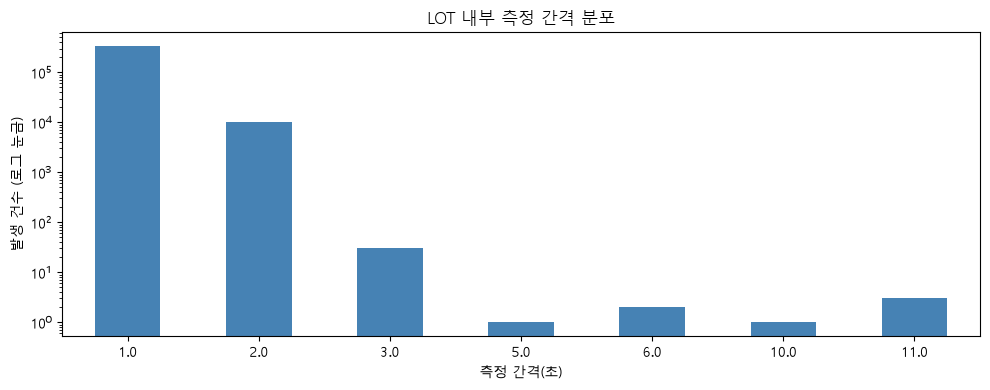

In [10]:
# [목적] CSV를 다시 읽어 이 셀만 실행해도 측정 간격 결과를 얻을 수 있게 합니다.
# [확인] 시각 변환 실패가 0건이고 MEAS_DT가 datetime64 자료형인지 확인합니다.
import matplotlib.pyplot as plt
from IPython.display import display

# 기존 df와 구분되는 이름으로 다시 읽어 이 추가 셀의 계산이 앞쪽 변수 변경에 영향을 덜 받게 합니다.
sampling_df = pd.read_csv(TEMP_CSV, encoding="utf-8")
sampling_df["MEAS_DT"] = pd.to_datetime(sampling_df["MEAS_DT"], errors="coerce")
print(f"전체 행 수: {len(sampling_df):,}행")
print(f"시각 변환 실패: {sampling_df['MEAS_DT'].isna().sum():,}건")
print(f"측정 기간: {sampling_df['MEAS_DT'].min()} ~ {sampling_df['MEAS_DT'].max()}")

# [목적] 서로 다른 LOT 사이의 비가동 시간을 제외하고 LOT 내부 측정 간격을 계산합니다.
sampling_df = sampling_df.sort_values(["LOT_NO", "MEAS_DT"]).reset_index(drop=True)
# 괄호를 사용하면 긴 계산식을 여러 줄로 나눠 읽기 쉽게 작성할 수 있습니다.
sampling_df["간격_초"] = (
    sampling_df.groupby("LOT_NO")["MEAS_DT"].diff().dt.total_seconds()
)
sampling_gap_sec = sampling_df["간격_초"].dropna()

# [목적] 간격별 발생 건수와 전체 LOT 내부 간격 대비 비율을 표로 만듭니다.
# [확인] 가장 건수가 많은 간격이 대표 측정 주기입니다.
sampling_summary = pd.DataFrame({
    "건수": sampling_gap_sec.value_counts().sort_index(),
    "비율_%": (sampling_gap_sec.value_counts(normalize=True).sort_index() * 100).round(4),
})
display(sampling_summary)

# [목적] 대표 간격, 비율, 다른 간격을 자동으로 문장으로 출력합니다.
representative_sec = sampling_gap_sec.mode().iloc[0]
representative_count = int((sampling_gap_sec == representative_sec).sum())
representative_pct = (sampling_gap_sec == representative_sec).mean() * 100
other_intervals = sorted(sampling_gap_sec[sampling_gap_sec != representative_sec].unique())
print(
    f"온도 데이터는 LOT 내부에서 대부분 {representative_sec:g}초 간격으로 기록되었습니다. "
    f"{representative_count:,}건으로 전체 LOT 내부 간격의 {representative_pct:.2f}%입니다."
)
print("다른 측정 간격(초):", other_intervals)
print("중복 시각(0초 간격):", int((sampling_gap_sec == 0).sum()), "건")
print("역순 시각(음수 간격):", int((sampling_gap_sec < 0).sum()), "건")
print("최대 LOT 내부 간격:", sampling_gap_sec.max(), "초")

# [목적] 간격별 건수를 시각화합니다. 건수 차이가 커서 y축은 로그 눈금을 사용합니다.
# kind='bar'는 막대그래프, logy=True는 y축을 로그 눈금으로 지정합니다.
# 1초 건수와 3~11초 건수의 차이가 매우 크므로 일반 눈금보다 로그 눈금이 비교에 적합합니다.
ax = sampling_summary["건수"].plot(
    kind="bar", figsize=(10, 4), color="steelblue", logy=True
)
ax.set_title("LOT 내부 측정 간격 분포")
ax.set_xlabel("측정 간격(초)")
ax.set_ylabel("발생 건수 (로그 눈금)")
plt.xticks(rotation=0)
# tight_layout은 제목과 축 글자가 그림 밖으로 잘리는 것을 줄여줍니다.
plt.tight_layout()
plt.show()

## 추가 코드 실행 결과

| 항목 | 확인한 값 |
| --- | --- |
| 가장 흔한 기록 간격 | 1초 |
| 1초 간격 건수 | 334,966건 |
| 1초 간격 비율 | 96.99% |
| 다른 간격 | 2초, 3초, 5초, 6초, 10초, 11초 |
| 최대 LOT 내부 간격 | 11초 |
| 전체 행 수 | 345,390행 |

> 2초 간격이 10,372건 존재합니다. 실제 누락인지 정상적인 데이터 로거 동작인지는 설비 수집 사양 확인이 필요합니다.

### 시각화 1 — LOT별 불규칙 간격 비율

**왜 추가했는가:** 전체 데이터에서 1초가 96.99%라는 결과만 보면 일부 LOT에 문제가 집중되어 있는지 알 수 없습니다. LOT별로 1초 초과 간격의 비율을 비교하면 특정 생산 구간이나 수집 세션의 문제 가능성을 찾을 수 있습니다.

**어떤 부분을 보면 좋은가:**

- 막대가 다른 LOT보다 유난히 높은 LOT가 있는지 봅니다.
- 불규칙 비율뿐 아니라 표의 `최대_간격_초`도 함께 확인합니다.
- 행 수가 작은 LOT는 비율이 쉽게 커질 수 있으므로 `전체_간격_수`도 같이 봅니다.

**점검할 것:** 특정 LOT의 불규칙 비율이 높다면 해당 시기의 네트워크, 데이터 로거, 설비 정지 기록과 대조해야 합니다. 2초 간격이 정상 사양이라면 `> 1초` 대신 현장 허용 기준으로 조건을 바꿔야 합니다.

,전체_간격_수,불규칙_간격_수,최대_간격_초,불규칙_비율_%
LOT_NO,,,,
240069,46835,1894,11.0,4.044
240037,35347,1326,3.0,3.751
240117,25707,947,3.0,3.684
240133,6217,226,3.0,3.635
240108,26981,969,3.0,3.591
240058,12558,450,3.0,3.583
240024,31728,1129,11.0,3.558
240044,4333,145,2.0,3.346
240001,40401,908,3.0,2.247


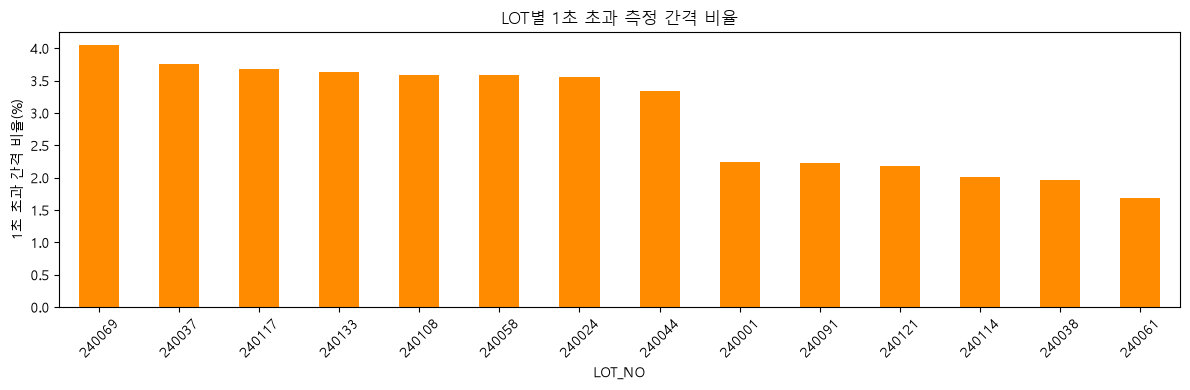

In [9]:
# 같은 LOT 내부 간격을 원본 분석용 데이터에 저장합니다.
# LOT별 diff 결과를 df에 새 컬럼으로 저장해 이후 집계와 시점 조회에서 함께 사용합니다.
df["간격_초"] = df.groupby("LOT_NO")["MEAS_DT"].diff().dt.total_seconds()

# 메서드 체이닝: 결측 제거 → LOT별 그룹 생성 → 여러 통계 집계 순서로 실행됩니다.
lot_interval_summary = (
    # 각 LOT의 첫 행은 이전 시각이 없어 간격이 NaN이므로 집계에서 제외합니다.
    df.dropna(subset=["간격_초"])
      .groupby("LOT_NO")
      .agg(
          전체_간격_수=("간격_초", "size"),
          # lambda는 LOT별 간격 중 1초를 초과한 값의 개수를 계산하는 짧은 함수입니다.
          불규칙_간격_수=("간격_초", lambda x: (x > 1).sum()),
          최대_간격_초=("간격_초", "max"),
      )
)
# LOT 크기가 서로 다르므로 단순 건수 대신 전체 간격 수로 나눈 비율도 계산합니다.
lot_interval_summary["불규칙_비율_%"] = (
    lot_interval_summary["불규칙_간격_수"]
    / lot_interval_summary["전체_간격_수"] * 100
).round(3)
display(lot_interval_summary.sort_values("불규칙_비율_%", ascending=False))

# 비율이 높은 LOT부터 왼쪽에 배치하여 우선 점검 대상을 쉽게 찾습니다.
ax = lot_interval_summary["불규칙_비율_%"].sort_values(ascending=False).plot(
    kind="bar", figsize=(12, 4), color="darkorange"
)
ax.set_title("LOT별 1초 초과 측정 간격 비율")
ax.set_xlabel("LOT_NO")
ax.set_ylabel("1초 초과 간격 비율(%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 시각화 2 — 불규칙 간격이 발생한 시점

**왜 추가했는가:** 같은 수의 공백이라도 한 시점에 몰려 발생한 경우와 전체 기간에 고르게 발생한 경우는 원인이 다를 수 있습니다. 발생 시각과 간격 크기를 함께 보면 일시적인 수집 장애와 반복적인 로거 특성을 구분하는 데 도움이 됩니다.

**어떤 부분을 보면 좋은가:**

- 점이 특정 시간대에 무더기로 모여 있는지 봅니다.
- 3초 이상처럼 위쪽에 있는 큰 공백을 우선 확인합니다.
- 색이 같은 점은 같은 LOT이므로 특정 LOT에 집중되는지도 확인합니다.

**점검할 것:** 큰 공백의 직전·직후 센서값, 설비 정지 여부, 조업 이벤트 시각을 대조해야 합니다. LOT 사이 공백은 이미 제외되었으므로 이 그래프의 점은 모두 LOT 내부에서 발생한 간격입니다.

1초 초과 LOT 내부 간격: 10,410건


,MEAS_DT,LOT_NO,간격_초
151055,2024-07-07 18:41:56,240069,11.0
66077,2024-03-08 04:45:06,240024,11.0
180892,2024-07-08 03:18:57,240069,11.0
112979,2024-04-16 13:08:41,240038,10.0
218191,2024-09-09 05:31:41,240091,6.0
264841,2024-11-04 18:02:30,240114,6.0
111650,2024-04-16 12:45:49,240038,5.0
126484,2024-06-09 07:32:49,240058,3.0
126434,2024-06-09 07:31:46,240058,3.0
164162,2024-07-07 22:29:04,240069,3.0


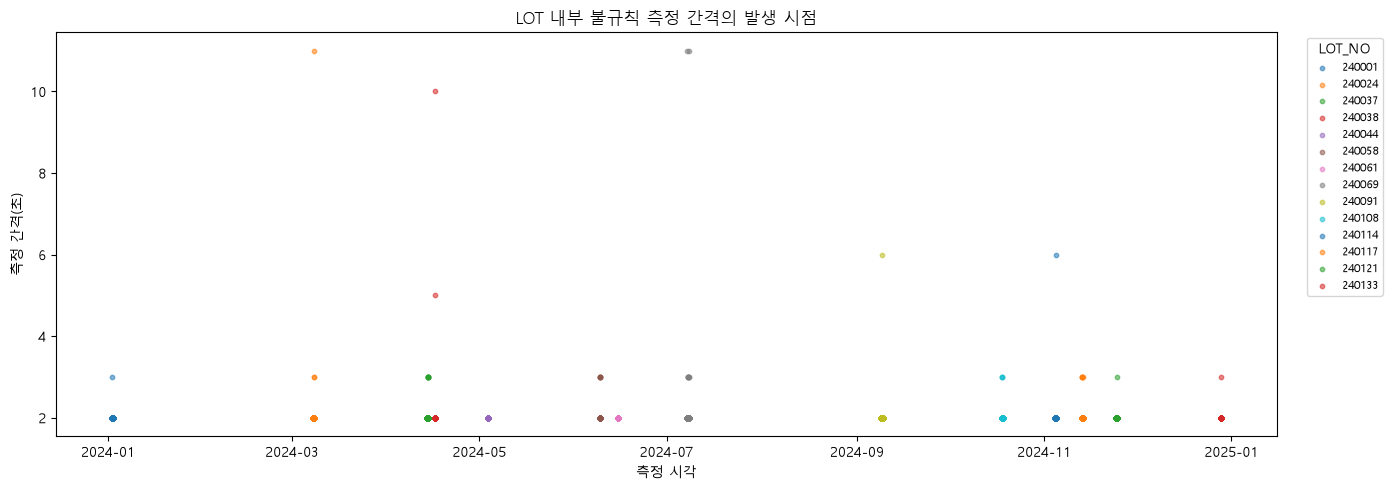

In [11]:
# loc[조건, 컬럼]으로 1초 초과 행과 필요한 세 컬럼만 선택합니다.
# copy를 사용해 원본 df와 독립된 점검용 DataFrame을 만듭니다.
irregular = df.loc[df["간격_초"] > 1, ["MEAS_DT", "LOT_NO", "간격_초"]].copy()
print(f"1초 초과 LOT 내부 간격: {len(irregular):,}건")
display(irregular.sort_values("간격_초", ascending=False).head(20))

# subplots는 그래프 전체(fig)와 실제 축(ax)을 반환합니다. figsize는 가로·세로 크기입니다.
fig, ax = plt.subplots(figsize=(14, 5))
# LOT별로 반복하면서 서로 다른 범례 항목을 가진 점을 그립니다.
for lot_no, part in irregular.groupby("LOT_NO"):
    # x축은 발생 시각, y축은 간격 크기입니다. s는 점 크기, alpha는 투명도입니다.
    ax.scatter(part["MEAS_DT"], part["간격_초"], s=10, alpha=0.55, label=str(lot_no))
ax.set_title("LOT 내부 불규칙 측정 간격의 발생 시점")
ax.set_xlabel("측정 시각")
ax.set_ylabel("측정 간격(초)")
# bbox_to_anchor로 범례를 그래프 오른쪽 밖에 배치해 데이터 점을 가리지 않게 합니다.
ax.legend(title="LOT_NO", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### 최종 해석 시 꼭 확인할 사항

1. **대표 간격:** 최빈값과 중앙값이 모두 1초인지 확인합니다.
2. **분모:** 전체 행 수가 아니라 LOT별 첫 행을 제외한 `345,376개` 간격을 비율의 분모로 사용했는지 확인합니다.
3. **LOT 경계:** 서로 다른 LOT 사이의 장기 공백을 센서 누락으로 계산하지 않았는지 확인합니다.
4. **중복·역순:** 0초 또는 음수 간격이 있는지 확인합니다. 현재 결과는 모두 0건입니다.
5. **2초 간격:** 10,372건이므로 단순한 우연으로 보기 어렵습니다. 수집기 사양상 허용된 동작인지 확인해야 합니다.
6. **큰 공백:** 최대 11초 간격의 원인을 원본 행과 조업 이벤트에서 확인합니다.
7. **결론 표현:** 현장 사양 확인 전에는 2초 이상을 확정적인 데이터 누락이라고 표현하지 않고 `불규칙 간격` 또는 `누락 후보`라고 기록합니다.